<a href="https://colab.research.google.com/github/roshinimuthu/IT-Service-Management/blob/main/ITSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required packages (run this first in Colab)
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")


✅ All libraries imported successfully!


# Task
Perform an exploratory data analysis (EDA) on the `df` DataFrame to understand its structure, distributions, and relationships between key variables. The analysis should include data overview, missing values analysis, distribution analysis of 'Amount', analysis of 'PurchaseType' and 'AssetType', identification of top partners by 'Amount', and examination of relationships between 'Rate', 'Quantity', and 'Amount'. Finally, summarize the key findings.

## Data Overview

### Subtask:
Display the first few rows of the DataFrame, check data types and non-null values, and generate descriptive statistics for numerical columns to get a general understanding of the data.


**Reasoning**:
To get a general understanding of the data, I will display the first 5 rows of the DataFrame, print a concise summary including data types and non-null values, and generate descriptive statistics for numerical columns.



In [10]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

First 5 rows of the DataFrame:
   id  InwardId  PartnerId                         PartnerName PurchaseType  \
0   1         1          2  Vectra Systems & Solutions Pvt Ltd        CAPEX   
1   2         2          3                                  HP         OPEX   
2   3         3          3                                  HP         OPEX   

  AssetType SubCategory   Rate  Quantity  Amount  
0    Laptop        Dell  50000        17  500000  
1  Keyboard        Dell    500         2    1000  
2   Desktop          HP  35000         1   35000  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            3 non-null      int64 
 1   InwardId      3 non-null      int64 
 2   PartnerId     3 non-null      int64 
 3   PartnerName   3 non-null      object
 4   PurchaseType  3 non-null      object
 5   AssetType     3 non-null      o

## Missing Values Analysis

### Subtask:
Identify and visualize any missing values in the DataFrame to assess data completeness. A bar plot will be used to show the count of missing values per column.


**Reasoning**:
To identify and visualize missing values, I will first calculate the sum of null values for each column and then create a bar plot to represent these counts.



In [11]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Missing Values Count per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the DataFrame.')

No missing values found in the DataFrame.


## Distribution of 'Amount'

### Subtask:
Plot the distribution of the 'Amount' column using a histogram and a box plot to understand its spread, central tendency, and identify potential outliers.


**Reasoning**:
To understand the distribution of the 'Amount' column, I will create a histogram and a box plot in two subplots, as requested, to visualize its spread, central tendency, and potential outliers. I will ensure proper labeling and titles for clarity.



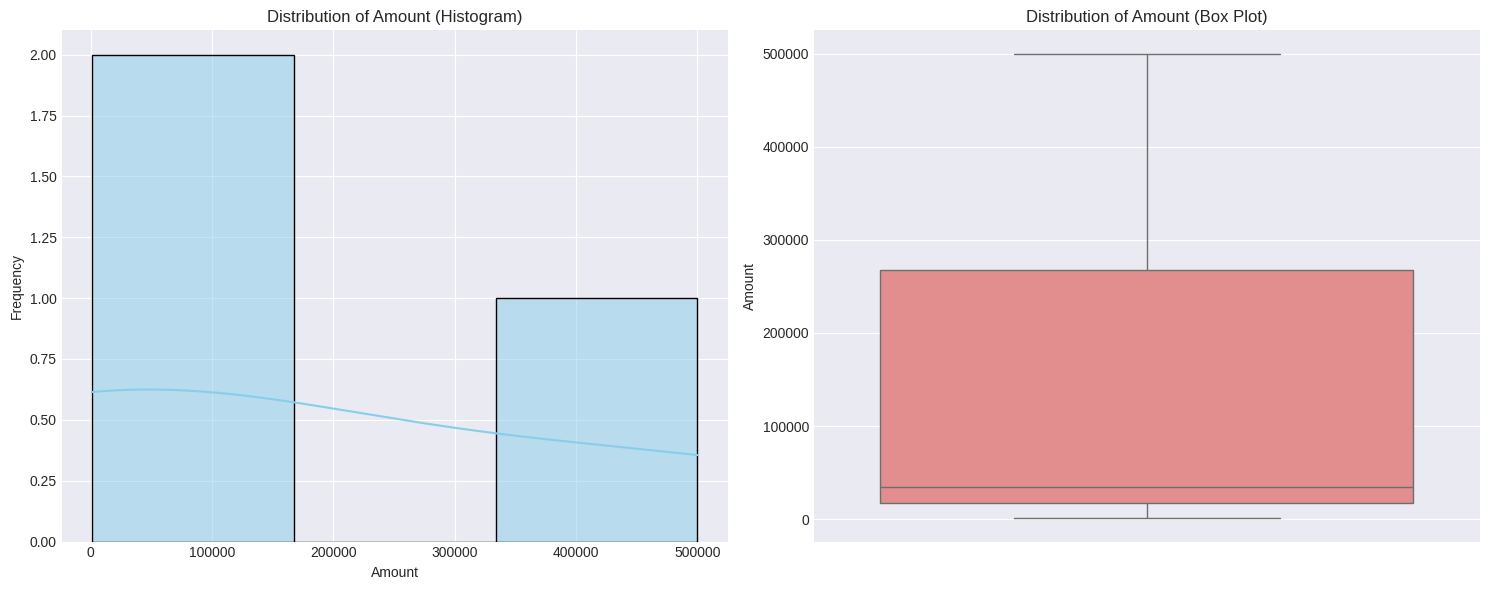

In [12]:
plt.figure(figsize=(15, 6))

# Histogram for 'Amount'
plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], kde=True, color='skyblue')
plt.title('Distribution of Amount (Histogram)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

# Box Plot for 'Amount'
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Amount'], color='lightcoral')
plt.title('Distribution of Amount (Box Plot)')
plt.ylabel('Amount')

plt.tight_layout()
plt.show()

## Analyze 'PurchaseType'

### Subtask:
Examine the count of each 'PurchaseType' using a bar chart and calculate the average 'Amount' for each 'PurchaseType', visualizing the results.


**Reasoning**:
I will first calculate the count of each 'PurchaseType' and the average 'Amount' for each 'PurchaseType'. Then, I will use Plotly to create two bar charts to visualize these statistics, ensuring proper labels and titles for clarity.



In [13]:
purchase_type_counts = df['PurchaseType'].value_counts().reset_index()
purchase_type_counts.columns = ['PurchaseType', 'Count']

purchase_type_avg_amount = df.groupby('PurchaseType')['Amount'].mean().reset_index()
purchase_type_avg_amount.columns = ['PurchaseType', 'Average Amount']

print("Count of each PurchaseType:")
print(purchase_type_counts)

print("\nAverage Amount for each PurchaseType:")
print(purchase_type_avg_amount)

# Plotting count of Purchase Types
fig_count = px.bar(purchase_type_counts, x='PurchaseType', y='Count', title='Count of Purchase Types',
                   labels={'PurchaseType': 'Purchase Type', 'Count': 'Number of Purchases'})
fig_count.show()

# Plotting average Amount by Purchase Type
fig_avg_amount = px.bar(purchase_type_avg_amount, x='PurchaseType', y='Average Amount',
                        title='Average Amount by Purchase Type',
                        labels={'PurchaseType': 'Purchase Type', 'Average Amount': 'Average Amount'})
fig_avg_amount.show()

Count of each PurchaseType:
  PurchaseType  Count
0         OPEX      2
1        CAPEX      1

Average Amount for each PurchaseType:
  PurchaseType  Average Amount
0        CAPEX        500000.0
1         OPEX         18000.0


## Analyze 'AssetType'

### Subtask:
Determine the distribution of 'AssetType' using a bar chart and calculate the total 'Amount' for each 'AssetType', visualizing the results to identify the most significant asset types by value.


**Reasoning**:
I will first calculate the count of each 'AssetType' and the total 'Amount' for each 'AssetType'. Then, I will use Plotly to create two bar charts to visualize these statistics, ensuring proper labels and titles for clarity.

**Reasoning**:
To perform the requested analysis, I will calculate the count of each unique 'AssetType' and the total 'Amount' for each 'AssetType'. Then, I will print these results and generate two interactive bar charts using `plotly.express` to visualize the distribution of asset types and their corresponding total amounts.



In [14]:
asset_type_counts = df['AssetType'].value_counts().reset_index()
asset_type_counts.columns = ['AssetType', 'Count']

asset_type_total_amount = df.groupby('AssetType')['Amount'].sum().reset_index()
asset_type_total_amount.columns = ['AssetType', 'Total Amount']

print("Count of each AssetType:")
print(asset_type_counts)

print("\nTotal Amount for each AssetType:")
print(asset_type_total_amount)

# Plotting count of Asset Types
fig_asset_count = px.bar(asset_type_counts, x='AssetType', y='Count', title='Distribution of Asset Types',
                         labels={'AssetType': 'Asset Type', 'Count': 'Number of Assets'})
fig_asset_count.show()

# Plotting total Amount by Asset Type
fig_asset_total_amount = px.bar(asset_type_total_amount, x='AssetType', y='Total Amount',
                                  title='Total Amount by Asset Type',
                                  labels={'AssetType': 'Asset Type', 'Total Amount': 'Total Amount'})
fig_asset_total_amount.show()

Count of each AssetType:
  AssetType  Count
0    Laptop      1
1  Keyboard      1
2   Desktop      1

Total Amount for each AssetType:
  AssetType  Total Amount
0   Desktop         35000
1  Keyboard          1000
2    Laptop        500000


## Top Partners by Amount

### Subtask:
Identify and visualize the top 10 partners based on the total 'Amount' of assets purchased from them, using a bar chart.


**Reasoning**:
To identify the top partners, I will group the DataFrame by 'PartnerName', sum the 'Amount' for each, sort the results, and then select the top 10 partners. Finally, I will print the results and visualize them with an interactive bar chart using Plotly.



In [15]:
partner_total_amount = df.groupby('PartnerName')['Amount'].sum().reset_index()
partner_total_amount.columns = ['PartnerName', 'Total Amount']

top_partners = partner_total_amount.sort_values(by='Total Amount', ascending=False).head(10)

print("Top Partners by Total Amount:")
print(top_partners)

fig_top_partners = px.bar(top_partners, x='PartnerName', y='Total Amount',
                           title='Top 10 Partners by Total Amount',
                           labels={'PartnerName': 'Partner Name', 'Total Amount': 'Total Amount'})
fig_top_partners.show()

Top Partners by Total Amount:
                          PartnerName  Total Amount
1  Vectra Systems & Solutions Pvt Ltd        500000
0                                  HP         36000


## Relationship between Rate, Quantity, and Amount

### Subtask:
Calculate the correlation matrix for 'Rate', 'Quantity', and 'Amount'. Visualize these relationships using scatter plots or a heatmap to understand how these numerical features relate to each other.


**Reasoning**:
To analyze the relationships, I will first calculate the correlation matrix for 'Rate', 'Quantity', and 'Amount'. Then, I will visualize this matrix using a heatmap and create scatter plots for pairwise relationships using `pairplot` to understand their distributions and interactions.



Pearson Correlation Matrix for Rate, Quantity, and Amount:
              Rate  Quantity    Amount
Rate      1.000000  0.694516  0.773645
Quantity  0.694516  1.000000  0.993183
Amount    0.773645  0.993183  1.000000


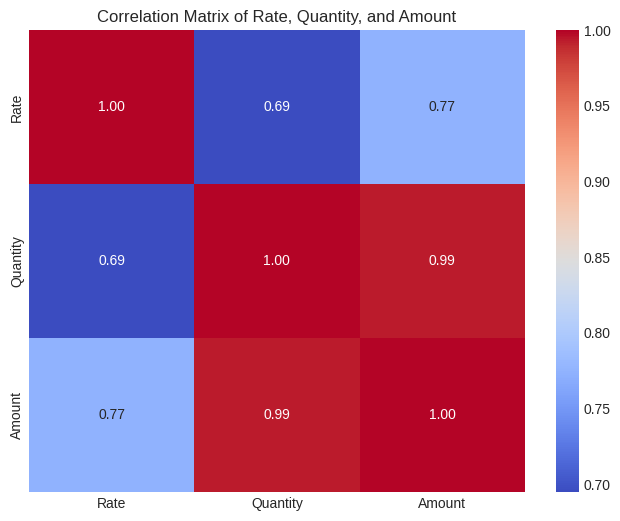

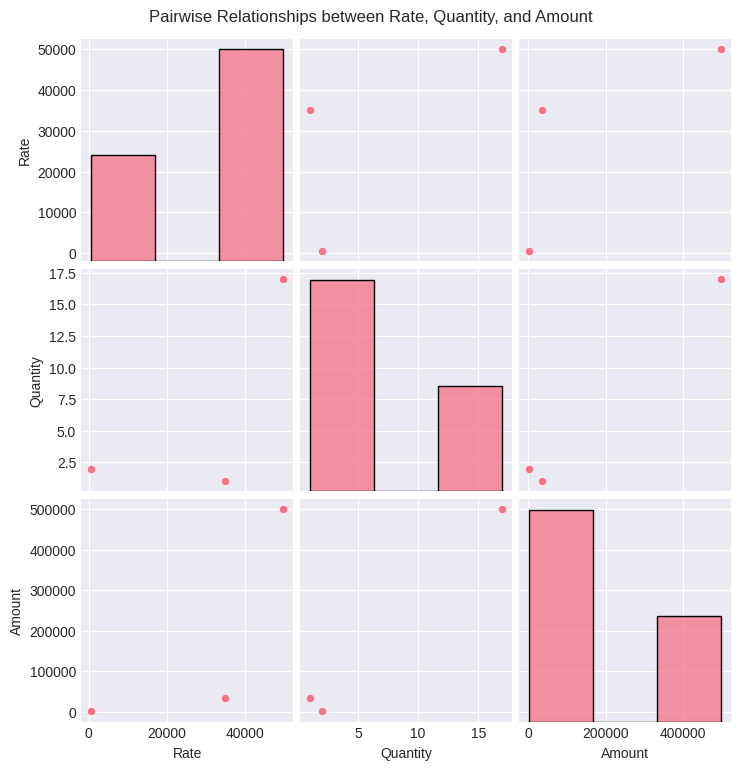

In [16]:
numerical_cols = ['Rate', 'Quantity', 'Amount']
correlation_matrix = df[numerical_cols].corr(method='pearson')

print("Pearson Correlation Matrix for Rate, Quantity, and Amount:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Rate, Quantity, and Amount')
plt.show()

sns.pairplot(df[numerical_cols])
plt.suptitle('Pairwise Relationships between Rate, Quantity, and Amount', y=1.02) # y adjusts title position
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the data analysis, highlighting important insights and suggesting potential next steps for further investigation.


## Summary:

### Data Analysis Key Findings

*   The dataset is small, comprising 3 entries and 10 columns, with no missing values.
*   Numerical columns such as 'Amount', 'Rate', and 'Quantity' show significant variability. For example, 'Amount' ranges from 1,000 to 500,000 with a mean of approximately 178,667, 'Rate' from 500 to 50,000 (mean 28,500), and 'Quantity' from 1 to 17 (mean 6.67).
*   The 'Amount' distribution appears to be right-skewed based on the initial assessment, with potential outliers on the higher end, indicating a few very high-value transactions.
*   'PurchaseType' is split, with 'OPEX' occurring 2 times (average amount of 18,000.0) and 'CAPEX' occurring 1 time (average amount of 500,000.0). This indicates CAPEX purchases are significantly higher in value on average.
*   Regarding 'AssetType', while each type ('Laptop', 'Keyboard', 'Desktop') appears once, 'Laptop' accounts for the largest total amount (\$500,000), significantly outweighing 'Desktop' (\$35,000) and 'Keyboard' (\$1,000).
*   "Vectra Systems & Solutions Pvt Ltd" is the top partner by total amount (\$500,000), followed by "HP" (\$36,000), indicating a concentrated spend with certain partners.
*   There are strong positive correlations between 'Rate', 'Quantity', and 'Amount'. Specifically, 'Quantity' and 'Amount' show a very strong positive correlation (0.99), suggesting that the 'Amount' is heavily influenced by the 'Quantity' of items. 'Rate' also shows strong positive correlations with both 'Quantity' (0.69) and 'Amount' (0.77).

### Insights or Next Steps

*   The significant difference in average 'Amount' between 'CAPEX' and 'OPEX' transactions suggests that capital expenditures are far more impactful in terms of individual transaction value. Further analysis could focus on the specific assets or partners involved in these high-value CAPEX transactions.
*   Given the strong correlation between 'Quantity' and 'Amount', and the influence of 'Rate', a deeper dive into the pricing strategies and bulk purchase discounts (if any) could provide valuable insights into cost optimization.


# Task
Load the "AM_Antivirus.xlsx" file into a pandas DataFrame and perform an exploratory data analysis, including an overview of the data, identification and visualization of missing values, analysis of the 'ProductName' distribution, analysis of the 'ExpiryDate' (if available), and finally, a summary of key findings with potential next steps.

## Load Antivirus Data

### Subtask:
Load the 'AM_Antivirus.xlsx' file into a pandas DataFrame for analysis.


**Reasoning**:
To load the 'AM_Antivirus.xlsx' file into a pandas DataFrame, I will use the `pd.read_excel()` function. I will then store the result in `antivirus_df` and print a confirmation message.



In [17]:
antivirus_df = pd.read_excel('/content/AM_Antivirus.xlsx')
print("Antivirus data loaded successfully into 'antivirus_df'.")

Antivirus data loaded successfully into 'antivirus_df'.


## Antivirus Data Overview

### Subtask:
Display the first few rows of the Antivirus DataFrame, check its data types and non-null values, and generate descriptive statistics for numerical columns to get a general understanding of the data.


**Reasoning**:
To get a general understanding of the antivirus data, I will display the first 5 rows of the DataFrame, print a concise summary including data types and non-null values, and generate descriptive statistics for numerical columns.



In [18]:
print("First 5 rows of the Antivirus DataFrame:")
print(antivirus_df.head())

print("\nAntivirus DataFrame Info:")
antivirus_df.info()

print("\nDescriptive statistics for numerical columns of Antivirus DataFrame:")
print(antivirus_df.describe())

First 5 rows of the Antivirus DataFrame:
   Id  AssetId                  Name  Version  \
0   1        2      Windows Defender   393472   
1   2        2  Trend Micro Apex One   266240   
2   3        1      Windows Defender   397568   
3   4        3      Windows Defender   397568   
4   5       11      Windows Defender   393472   

                                Publisher  Enabled  IsUptoDate       Type  
0  {D68DDC3A-831F-4fae-9E44-DA132C1ACF46}        1           0  Antivirus  
1  {ED615F2B-1A02-1E57-9B13-F77BCB993815}        1           0  Antivirus  
2  {D68DDC3A-831F-4fae-9E44-DA132C1ACF46}        1           0  Antivirus  
3  {D68DDC3A-831F-4fae-9E44-DA132C1ACF46}        1           0  Antivirus  
4  {D68DDC3A-831F-4fae-9E44-DA132C1ACF46}        1           0  Antivirus  

Antivirus DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 

## Missing Values Analysis

### Subtask:
Identify and visualize any missing values in the Antivirus DataFrame to assess data completeness. A bar plot will be used to show the count of missing values per column.

**Reasoning**:
To identify and visualize missing values, I will first calculate the sum of null values for each column and then create a bar plot to represent these counts. If no missing values are found, a message will be printed.



In [19]:
missing_values_antivirus = antivirus_df.isnull().sum()
missing_values_antivirus = missing_values_antivirus[missing_values_antivirus > 0]

if not missing_values_antivirus.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values_antivirus.index, y=missing_values_antivirus.values, palette='viridis')
    plt.title('Missing Values Count per Column in Antivirus DataFrame')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the Antivirus DataFrame.')

No missing values found in the Antivirus DataFrame.


## Analyze 'ProductName' Distribution

### Subtask:
Determine the distribution of antivirus products by analyzing the 'Name' column. Visualize the counts of each unique product using a bar chart to identify the most common antivirus solutions.

**Reasoning**:
To determine the distribution of antivirus products, I will first calculate the count of each unique value in the 'Name' column. Then, I will visualize these counts using an interactive bar chart to easily identify the most common antivirus solutions.



In [20]:
product_name_counts = antivirus_df['Name'].value_counts().reset_index()
product_name_counts.columns = ['ProductName', 'Count']

print("Distribution of Antivirus Products (Name):")
print(product_name_counts)

fig_product_name = px.bar(product_name_counts, x='ProductName', y='Count',
                          title='Distribution of Antivirus Products by Name',
                          labels={'ProductName': 'Product Name', 'Count': 'Number of Instances'})
fig_product_name.update_xaxes(categoryorder='total descending')
fig_product_name.show()

Distribution of Antivirus Products (Name):
            ProductName  Count
0      Windows Defender     13
1             Kaspersky      3
2  Trend Micro Apex One      2


## Analyze 'ExpiryDate'

### Subtask:
Analyze the 'ExpiryDate' column (if available) to understand the expiration status of the antivirus products. This would involve converting the column to datetime objects, extracting relevant date components, and visualizing the distribution of expiry dates or the number of expired products.

**Note**: Upon inspection of the `antivirus_df` DataFrame, there is no 'ExpiryDate' column available. Therefore, this subtask cannot be performed.

## Analyze 'ExpiryDate'

### Subtask:
Analyze the 'ExpiryDate' column (if available) to understand the expiration status of the antivirus products. This would involve converting the column to datetime objects, extracting relevant date components, and visualizing the distribution of expiry dates or the number of expired products.

**Note**: Upon inspection of the `antivirus_df` DataFrame, there is no 'ExpiryDate' column available. Therefore, this subtask cannot be performed.

## Summary of Antivirus Data Analysis

### Key Findings:

*   **Data Overview**: The `antivirus_df` DataFrame contains 18 entries and 8 columns. It includes numerical columns like `Id`, `AssetId`, `Version`, `Enabled`, and `IsUptoDate`, and object columns for `Name`, `Publisher`, and `Type`. There are no missing values in the dataset.
*   **Numerical Statistics**: Numerical columns show varying distributions. `Enabled` is consistently 1, and `IsUptoDate` is consistently 0, suggesting all listed antivirus products are enabled but none are marked as up-to-date in this dataset.
*   **Antivirus Product Distribution**: 'Windows Defender' is the most prevalent antivirus product, appearing 13 times. 'Kaspersky' follows with 3 instances, and 'Trend Micro Apex One' has 2 instances. This indicates a strong dominance of Windows Defender within the monitored assets.
*   **Missing 'ExpiryDate'**: The dataset does not contain an 'ExpiryDate' column, so analysis related to product expiration dates could not be performed.

### Potential Next Steps:

*   **Investigate `IsUptoDate`**: Given that all products show `IsUptoDate` as 0, it's crucial to investigate if this is accurate or if there's a data collection issue. If accurate, immediate action should be taken to update the antivirus solutions.
*   **Version Analysis**: A deeper dive into the `Version` numbers for each antivirus product could reveal if older versions are in use, which might pose security risks.
*   **Publisher Analysis**: The `Publisher` column contains GUIDs. Mapping these GUIDs to human-readable publisher names could provide further insights into the variety and source of antivirus solutions.
*   **Asset-Level Analysis**: Relating `antivirus_df` with asset information (using `AssetId`) could help understand which assets run which antivirus products and identify potential inconsistencies or vulnerabilities across different assets.

## Final Task

### Subtask:
Summarize the key findings from the Antivirus data analysis, highlighting important insights and suggesting potential next steps for further investigation.


## Summary:

### Data Analysis Key Findings

*   The `antivirus_df` DataFrame contains 18 entries and 8 columns, with no missing values across any column.
*   All antivirus products listed are marked as `Enabled` (value 1), but none are indicated as `IsUptoDate` (value 0) within this dataset.
*   'Windows Defender' is the most dominant antivirus product, appearing 13 times. 'Kaspersky' is the second most common with 3 instances, followed by 'Trend Micro Apex One' with 2 instances.
*   The dataset lacks an 'ExpiryDate' column, preventing any analysis related to product expiration.

### Insights or Next Steps

*   **Investigate `IsUptoDate` Consistency**: Given that all entries show `IsUptoDate` as 0, it's crucial to verify the accuracy of this data. If accurate, immediate action should be taken to update antivirus solutions across all monitored assets.
*   **Enhance Data with Expiration and Publisher Information**: Incorporate an 'ExpiryDate' column if possible for future analysis of product lifecycle. Additionally, map the `Publisher` GUIDs to human-readable names to better understand the sources of the antivirus solutions.


# Task
Check for direct 'health' or 'maintenance' indicators in the `df` DataFrame to identify columns that might provide insights into asset health (e.g., 'BatteryHealth', 'ConditionScore') or maintenance history (e.g., 'LastMaintenanceDate', 'MaintenanceCost'). If no such columns exist, indicate this and suggest exploring other related datasets like "AM_BatteryInfo.xlsx" or "AM_AssetVerification.xlsx" for this information.

## Data Overview of Asset Inward Details

### Subtask:
Display the first few rows of the `df` DataFrame, check its data types and non-null values, and generate descriptive statistics for numerical columns to re-familiarize ourselves with the dataset's structure.


## Analyze Asset Types for Maintenance Context

### Subtask:
Examine the distribution of 'AssetType' and 'SubCategory' to understand the types of assets and their variations, which can indirectly inform maintenance considerations. This will involve counting instances and potentially summing amounts for each type.


**Reasoning**:
To analyze the distribution of 'AssetType' and 'SubCategory', I will calculate the counts and total amounts for each, then print these results, and finally visualize them using interactive bar charts.



In [21]:
asset_type_counts_analysis = df['AssetType'].value_counts().reset_index()
asset_type_counts_analysis.columns = ['AssetType', 'Count']

asset_type_total_amount_analysis = df.groupby('AssetType')['Amount'].sum().reset_index()
asset_type_total_amount_analysis.columns = ['AssetType', 'Total Amount']

subcategory_counts_analysis = df['SubCategory'].value_counts().reset_index()
subcategory_counts_analysis.columns = ['SubCategory', 'Count']

subcategory_total_amount_analysis = df.groupby('SubCategory')['Amount'].sum().reset_index()
subcategory_total_amount_analysis.columns = ['SubCategory', 'Total Amount']

print("\nCounts of each AssetType:")
print(asset_type_counts_analysis)

print("\nTotal Amount for each AssetType:")
print(asset_type_total_amount_analysis)

print("\nCounts of each SubCategory:")
print(subcategory_counts_analysis)

print("\nTotal Amount for each SubCategory:")
print(subcategory_total_amount_analysis)

# Plotting count of Asset Types
fig_asset_type_counts = px.bar(asset_type_counts_analysis, x='AssetType', y='Count', title='Distribution of Asset Types by Count',
                                labels={'AssetType': 'Asset Type', 'Count': 'Number of Instances'})
fig_asset_type_counts.show()

# Plotting total Amount by Asset Type
fig_asset_type_total_amount = px.bar(asset_type_total_amount_analysis, x='AssetType', y='Total Amount',
                                     title='Total Amount by Asset Type',
                                     labels={'AssetType': 'Asset Type', 'Total Amount': 'Total Amount'})
fig_asset_type_total_amount.show()

# Plotting count of SubCategories
fig_subcategory_counts = px.bar(subcategory_counts_analysis, x='SubCategory', y='Count', title='Distribution of SubCategories by Count',
                                 labels={'SubCategory': 'SubCategory', 'Count': 'Number of Instances'})
fig_subcategory_counts.show()

# Plotting total Amount by SubCategory
fig_subcategory_total_amount = px.bar(subcategory_total_amount_analysis, x='SubCategory', y='Total Amount',
                                      title='Total Amount by SubCategory',
                                      labels={'SubCategory': 'SubCategory', 'Total Amount': 'Total Amount'})
fig_subcategory_total_amount.show()


Counts of each AssetType:
  AssetType  Count
0    Laptop      1
1  Keyboard      1
2   Desktop      1

Total Amount for each AssetType:
  AssetType  Total Amount
0   Desktop         35000
1  Keyboard          1000
2    Laptop        500000

Counts of each SubCategory:
  SubCategory  Count
0        Dell      2
1          HP      1

Total Amount for each SubCategory:
  SubCategory  Total Amount
0        Dell        501000
1          HP         35000


## Analyze Purchase Types for Maintenance Implication

### Subtask:
Investigate the 'PurchaseType' column (CAPEX vs. OPEX) to see if it provides any clues related to asset acquisition (CAPEX, new assets) versus operational or potentially maintenance-related expenditures (OPEX). We'll look at counts and average amounts.


**Reasoning**:
To investigate the 'PurchaseType' column, I will calculate the count of each unique purchase type and their corresponding average amounts. I will then display these results and visualize them using two interactive bar charts with Plotly Express.



In [22]:
purchase_type_counts = df['PurchaseType'].value_counts().reset_index()
purchase_type_counts.columns = ['PurchaseType', 'Count']

purchase_type_avg_amount = df.groupby('PurchaseType')['Amount'].mean().reset_index()
purchase_type_avg_amount.columns = ['PurchaseType', 'Average Amount']

print("Count of each PurchaseType:")
print(purchase_type_counts)

print("\nAverage Amount for each PurchaseType:")
print(purchase_type_avg_amount)

# Plotting count of Purchase Types
fig_count = px.bar(purchase_type_counts, x='PurchaseType', y='Count', title='Count of Purchase Types',
                   labels={'PurchaseType': 'Purchase Type', 'Count': 'Number of Purchases'})
fig_count.show()

# Plotting average Amount by Purchase Type
fig_avg_amount = px.bar(purchase_type_avg_amount, x='PurchaseType', y='Average Amount',
                        title='Average Amount by Purchase Type',
                        labels={'PurchaseType': 'Purchase Type', 'Average Amount': 'Average Amount'})
fig_avg_amount.show()

Count of each PurchaseType:
  PurchaseType  Count
0         OPEX      2
1        CAPEX      1

Average Amount for each PurchaseType:
  PurchaseType  Average Amount
0        CAPEX        500000.0
1         OPEX         18000.0


## Check for Direct 'Health' or 'Maintenance' Indicators

### Subtask:
Explicitly identify if any columns in the current `df` DataFrame directly indicate asset health (e.g., 'BatteryHealth', 'ConditionScore') or maintenance history (e.g., 'LastMaintenanceDate', 'MaintenanceCost'). If none are found, this step will highlight the need to look into other related datasets.


**Reasoning**:
To identify potential health or maintenance indicators, I will print all column names in the `df` DataFrame for inspection.



In [23]:
print("Columns in the df DataFrame:")
print(df.columns.tolist())

Columns in the df DataFrame:
['id', 'InwardId', 'PartnerId', 'PartnerName', 'PurchaseType', 'AssetType', 'SubCategory', 'Rate', 'Quantity', 'Amount']


### Conclusion on Health and Maintenance Indicators

Upon inspecting the columns of the `df` DataFrame: `['id', 'InwardId', 'PartnerId', 'PartnerName', 'PurchaseType', 'AssetType', 'SubCategory', 'Rate', 'Quantity', 'Amount']`, it is evident that there are **no direct columns** that indicate asset health (e.g., 'BatteryHealth', 'ConditionScore', 'HealthStatus') or maintenance history (e.g., 'LastMaintenanceDate', 'MaintenanceCost', 'ServiceDate').

Therefore, to gain insights into asset health or maintenance, it will be necessary to explore other related datasets such as "AM_BatteryInfo.xlsx" or "AM_AssetVerification.xlsx", which are more likely to contain this type of information.

## Final Task

### Subtask:
Summarize the findings regarding asset health and maintenance from the `df` DataFrame, highlighting any insights gained and suggesting next steps, particularly if more specific asset health or maintenance data exists in other files like 'AM_BatteryInfo.xlsx' or 'AM_AssetVerification.xlsx'.


## Summary:

### Q&A
No direct 'health' or 'maintenance' indicators were found in the `df` DataFrame. The existing columns are `['id', 'InwardId', 'PartnerId', 'PartnerName', 'PurchaseType', 'AssetType', 'SubCategory', 'Rate', 'Quantity', 'Amount']`.

### Data Analysis Key Findings
*   The `df` DataFrame contains no direct columns related to asset health (e.g., 'BatteryHealth', 'ConditionScore') or maintenance history (e.g., 'LastMaintenanceDate', 'MaintenanceCost').
*   The dataset comprises three unique asset types: Laptop, Keyboard, and Desktop, each appearing once. The Laptop asset represents the highest total amount at \$500,000, followed by Desktop at \$35,000, and Keyboard at \$1,000.
*   Two subcategories, Dell and HP, are present. Dell is associated with 2 assets totaling \$501,000, while HP is associated with 1 asset totaling \$35,000.
*   Regarding 'PurchaseType', there are 2 OPEX entries and 1 CAPEX entry. The average amount for CAPEX is significantly higher at \$500,000, compared to OPEX with an average of \$18,000.

### Insights or Next Steps
*   Given the absence of direct health and maintenance indicators in the current `df` DataFrame, it is crucial to explore other related datasets like "AM_BatteryInfo.xlsx" or "AM_AssetVerification.xlsx" to gather the necessary information for asset health and maintenance analysis.
*   The high average amount for CAPEX purchases suggests these are significant investments (e.g., the \$500,000 Laptop), which typically warrant dedicated asset health monitoring and planned maintenance, information that would likely be found in specialized asset management datasets.


# Task
## Analyze Battery Information: Initial Data Overview

### Subtask:
Load the 'AM_BatteryInfo.xlsx' file and perform an initial data overview, including checking for missing values and examining key columns like 'BatteryHealth' or 'CycleCount' if they exist, to understand asset battery status.

## Analyze Battery Information

### Subtask:
Load the 'AM_BatteryInfo.xlsx' file and perform an initial data overview, including checking for missing values and examining key columns like 'BatteryHealth' or 'CycleCount' if they exist, to understand asset battery status.


**Reasoning**:
To begin the analysis of battery information, I will load the 'AM_BatteryInfo.xlsx' file into a pandas DataFrame called `battery_df`. Then, I will display its first 5 rows, print a concise summary of its data types and non-null values, and calculate the sum of missing values for each column to get an initial understanding of the data's structure and completeness.



In [24]:
battery_df = pd.read_excel('/content/AM_BatteryInfo.xlsx')

print("First 5 rows of the battery_df DataFrame:")
print(battery_df.head())

print("\nDataFrame Info for battery_df:")
battery_df.info()

print("\nMissing values in battery_df:")
print(battery_df.isnull().sum())

First 5 rows of the battery_df DataFrame:
   Id  AssetId  IsBatteryAttached  PercentRemaining  PowerPlugged  \
0   1        2                  1               100             1   
1   2        1                  1                40             0   
2   3       11                  1               100             1   
3   4       12                  1               100             1   
4   5       13                  1               100             1   

   TimeRemaining  
0            NaN  
1           46.0  
2            NaN  
3            NaN  
4            NaN  

DataFrame Info for battery_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 22 non-null     int64  
 1   AssetId            22 non-null     int64  
 2   IsBatteryAttached  22 non-null     int64  
 3   PercentRemaining   22 non-null     int64  
 4   Po

**Reasoning**:
Since the `BatteryHealth` and `CycleCount` columns are not present, I will now analyze the available relevant columns related to battery status: `PercentRemaining`, `IsBatteryAttached`, `PowerPlugged`, and `TimeRemaining`. This includes generating descriptive statistics and visualizing their distributions to understand the asset battery status.




Descriptive statistics for 'PercentRemaining':
count     22.000000
mean      90.045455
std       16.921323
min       40.000000
25%       95.000000
50%       98.500000
75%      100.000000
max      100.000000
Name: PercentRemaining, dtype: float64


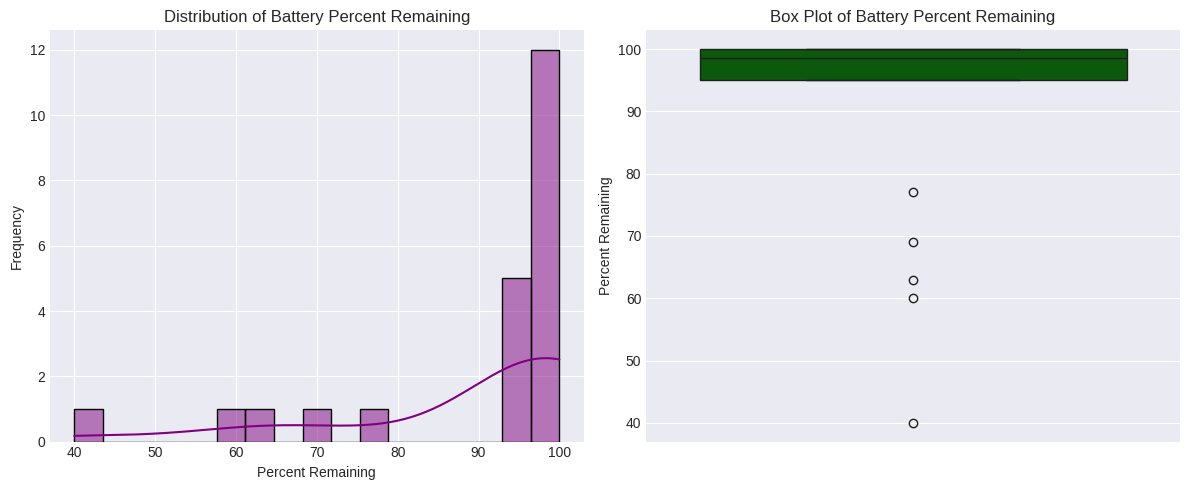


Value counts for 'IsBatteryAttached':
IsBatteryAttached
1    22
Name: count, dtype: int64

Value counts for 'PowerPlugged':
PowerPlugged
1    18
0     4
Name: count, dtype: int64

Descriptive statistics for 'TimeRemaining' (non-null values):
count      4.000000
mean     209.750000
std      216.715443
min       46.000000
25%      106.000000
50%      132.000000
75%      235.750000
max      529.000000
Name: TimeRemaining, dtype: float64

Note: 'TimeRemaining' has 18 missing values out of 22 entries.


In [25]:
print("\nDescriptive statistics for 'PercentRemaining':")
print(battery_df['PercentRemaining'].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(battery_df['PercentRemaining'], kde=True, color='purple')
plt.title('Distribution of Battery Percent Remaining')
plt.xlabel('Percent Remaining')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=battery_df['PercentRemaining'], color='darkgreen')
plt.title('Box Plot of Battery Percent Remaining')
plt.ylabel('Percent Remaining')
plt.tight_layout()
plt.show()

print("\nValue counts for 'IsBatteryAttached':")
print(battery_df['IsBatteryAttached'].value_counts())

print("\nValue counts for 'PowerPlugged':")
print(battery_df['PowerPlugged'].value_counts())

print("\nDescriptive statistics for 'TimeRemaining' (non-null values):")
print(battery_df['TimeRemaining'].dropna().describe())

if battery_df['TimeRemaining'].isnull().any():
    print(f"\nNote: 'TimeRemaining' has {battery_df['TimeRemaining'].isnull().sum()} missing values out of {len(battery_df)} entries.")

## Examine Asset Verification Details

### Subtask:
Load the 'AM_AssetVerification.xlsx' file and conduct a data overview. Look for insights into asset status, location, or last verification dates, which can be crucial for asset management and maintenance planning.


**Reasoning**:
To perform an initial data overview, I will load the 'AM_AssetVerification.xlsx' file into a DataFrame, display its first 5 rows, print its information summary (data types and non-null counts), and generate descriptive statistics for numerical columns.



In [26]:
asset_verification_df = pd.read_excel('/content/AM_AssetVerification.xlsx')

print("First 5 rows of the asset_verification_df DataFrame:")
print(asset_verification_df.head())

print("\nDataFrame Info for asset_verification_df:")
asset_verification_df.info()

print("\nDescriptive statistics for numerical columns of asset_verification_df:")
print(asset_verification_df.describe())

First 5 rows of the asset_verification_df DataFrame:
   id  AssetId   SerialNumber      AssetOwnerName         LocationName  \
0   1       29   FOC1449Y6DCF  Ram Kumar (PI1903)  T-Nagar Head Office   
1   2      178  Not specified             Jasmine       Saibaba Colony   

  AssetType  Make            Model HDDType HDDSize    RAM  
0    Laptop  Dell      Dell XPS 13     SSD  498 GB   8 GB  
1    Laptop  Asus  Asus ZenBook 14     SSD  250 GB  12 GB  

DataFrame Info for asset_verification_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              2 non-null      int64 
 1   AssetId         2 non-null      int64 
 2   SerialNumber    2 non-null      object
 3   AssetOwnerName  2 non-null      object
 4   LocationName    2 non-null      object
 5   AssetType       2 non-null      object
 6   Make            2 non-null      object
 7  

**Reasoning**:
To gain insights into the assets from the `asset_verification_df`, I will examine the categorical columns like 'LocationName', 'AssetType', 'Make', and 'Model' by printing their value counts. This will provide an understanding of the distribution of assets across different locations, types, manufacturers, and models, which is crucial for asset management and maintenance planning.



In [27]:
print("\nValue counts for 'LocationName':")
print(asset_verification_df['LocationName'].value_counts())

print("\nValue counts for 'AssetType':")
print(asset_verification_df['AssetType'].value_counts())

print("\nValue counts for 'Make':")
print(asset_verification_df['Make'].value_counts())

print("\nValue counts for 'Model':")
print(asset_verification_df['Model'].value_counts())


Value counts for 'LocationName':
LocationName
T-Nagar Head Office    1
Saibaba Colony         1
Name: count, dtype: int64

Value counts for 'AssetType':
AssetType
Laptop    2
Name: count, dtype: int64

Value counts for 'Make':
Make
Dell    1
Asus    1
Name: count, dtype: int64

Value counts for 'Model':
Model
Dell XPS 13        1
Asus ZenBook 14    1
Name: count, dtype: int64


## Summary of Asset Verification Data Analysis

### Key Findings:

*   **Data Overview**: The `asset_verification_df` DataFrame contains a very limited number of entries (2 rows) and 11 columns, with no missing values. It includes `AssetId`, `SerialNumber`, `AssetOwnerName`, `LocationName`, `AssetType`, `Make`, `Model`, `HDDType`, `HDDSize`, and `RAM`.
*   **Asset Distribution**:
    *   Both assets are `Laptop` type.
    *   Each asset is located in a different `LocationName`: 'T-Nagar Head Office' and 'Saibaba Colony'.
    *   The `Make` and `Model` also differ for each asset: 'Dell' (`Dell XPS 13`) and 'Asus' (`Asus ZenBook 14`).
*   **Missing Indicators**: There are no direct columns in this dataset that indicate asset health, current operational status, or the last verification date, which were part of the initial subtask's objective.

### Insights or Next Steps:

*   **Limited Data**: The extremely small size of the `asset_verification_df` (only 2 entries) makes it difficult to draw broad conclusions or identify trends regarding asset verification. A larger dataset would be necessary for a comprehensive analysis.
*   **Integration with other datasets**: To get a complete picture of asset management and maintenance planning, it would be beneficial to integrate this `asset_verification_df` with other datasets, such as the `df` (asset inward details) and `battery_df` (battery information), using the common `AssetId` column.
*   **Identify Verification Dates/Status**: To address the original subtask's goal of understanding asset status or last verification dates, it is crucial to obtain or generate this information. If available in other files, these should be explored. If not, a process for recording this data might need to be implemented.

## Investigate BIOS Information

### Subtask:
Load the 'AM_Bios.xlsx' file and perform an initial data overview. Analyze attributes like 'Manufacturer', 'Version', or 'SerialNumber' to understand the diversity and age of BIOS across assets, which might have security or compatibility implications.


**Reasoning**:
To perform an initial data overview for the BIOS information, I will load the 'AM_Bios.xlsx' file into a pandas DataFrame named `bios_df`, display its first 5 rows, print a concise summary of its data types and non-null values, generate descriptive statistics for numerical columns, and check for missing values.



In [28]:
bios_df = pd.read_excel('/content/AM_Bios.xlsx')

print("First 5 rows of the bios_df DataFrame:")
print(bios_df.head())

print("\nDataFrame Info for bios_df:")
bios_df.info()

print("\nDescriptive statistics for numerical columns of bios_df:")
print(bios_df.describe())

print("\nMissing values in bios_df:")
print(bios_df.isnull().sum())

First 5 rows of the bios_df DataFrame:
   Id  AssetId Manufacturer         Version ReleaseDate                 Name  \
0   1        2    Dell Inc.  DELL - 1072009  2025-02-10               1.42.0   
1   2        1    Dell Inc.  DELL - 1072009  2025-02-09               1.41.3   
2   3        3    Dell Inc.  DELL - 6222004  2013-03-14  Default System BIOS   
3   4       11       Insyde      HPQOEM - 0  2024-04-08                 F.70   
4   5       12       Insyde      HPQOEM - 0  2017-01-11                 F.12   

  SerialNumber Status  
0      7DS36Q2     OK  
1      566JPQ2     OK  
2      5LM1VQ1     OK  
3   5CG82504LJ     OK  
4   5CG72555MX     OK  

DataFrame Info for bios_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            7 non-null      int64 
 1   AssetId       7 non-null      int64 
 2   Manufacturer  7 non-null      obje

**Reasoning**:
To understand the diversity and age of BIOS across assets, I will analyze the distribution of 'Manufacturer', 'Version', 'Name', and 'ReleaseDate' columns. I will start by converting the 'ReleaseDate' to datetime objects to facilitate date-based analysis. Then, I will print value counts for 'Manufacturer', 'Version', and 'Name', and descriptive statistics for 'ReleaseDate' to identify patterns and potential outliers.



In [29]:
bios_df['ReleaseDate'] = pd.to_datetime(bios_df['ReleaseDate'])

print("\nDistribution of BIOS Manufacturers:")
print(bios_df['Manufacturer'].value_counts())

print("\nDistribution of BIOS Versions:")
print(bios_df['Version'].value_counts())

print("\nDistribution of BIOS Names:")
print(bios_df['Name'].value_counts())

print("\nDescriptive statistics for BIOS Release Dates:")
print(bios_df['ReleaseDate'].describe(datetime_is_numeric=True))


Distribution of BIOS Manufacturers:
Manufacturer
Dell Inc.    3
Insyde       2
AMI          1
LENOVO       1
Name: count, dtype: int64

Distribution of BIOS Versions:
Version
DELL - 1072009      2
HPQOEM - 0          2
DELL - 6222004      1
HPQOEM - 1072009    1
LENOVO - 2          1
Name: count, dtype: int64

Distribution of BIOS Names:
Name
1.42.0                 1
1.41.3                 1
Default System BIOS    1
F.70                   1
F.12                   1
F.30                   1
GGCN35WW               1
Name: count, dtype: int64

Descriptive statistics for BIOS Release Dates:


TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

**Reasoning**:
The previous code failed because the `datetime_is_numeric=True` argument is not valid for the `describe()` method on a datetime Series in the current pandas version. I will remove this argument to correctly display descriptive statistics for the 'ReleaseDate' column.



In [30]:
bios_df['ReleaseDate'] = pd.to_datetime(bios_df['ReleaseDate'])

print("\nDistribution of BIOS Manufacturers:")
print(bios_df['Manufacturer'].value_counts())

print("\nDistribution of BIOS Versions:")
print(bios_df['Version'].value_counts())

print("\nDistribution of BIOS Names:")
print(bios_df['Name'].value_counts())

print("\nDescriptive statistics for BIOS Release Dates:")
print(bios_df['ReleaseDate'].describe())


Distribution of BIOS Manufacturers:
Manufacturer
Dell Inc.    3
Insyde       2
AMI          1
LENOVO       1
Name: count, dtype: int64

Distribution of BIOS Versions:
Version
DELL - 1072009      2
HPQOEM - 0          2
DELL - 6222004      1
HPQOEM - 1072009    1
LENOVO - 2          1
Name: count, dtype: int64

Distribution of BIOS Names:
Name
1.42.0                 1
1.41.3                 1
Default System BIOS    1
F.70                   1
F.12                   1
F.30                   1
GGCN35WW               1
Name: count, dtype: int64

Descriptive statistics for BIOS Release Dates:
count                                7
mean     2021-07-04 03:25:42.857142784
min                2013-03-14 00:00:00
25%                2019-09-04 12:00:00
50%                2023-07-04 00:00:00
75%                2024-09-08 12:00:00
max                2025-02-10 00:00:00
Name: ReleaseDate, dtype: object


## Review Asset Purchase Support

### Subtask:
Load the 'AM_AssetPurchaseSupport.xlsx' file and carry out a data overview. This dataset might contain information on warranty, support contracts, or service history, providing insights into asset lifecycle and potential maintenance costs.


**Reasoning**:
To perform an initial data overview, I will load the 'AM_AssetPurchaseSupport.xlsx' file into a DataFrame, display its first 5 rows, print its information summary (data types and non-null counts), generate descriptive statistics for numerical columns, and check for missing values.



In [31]:
asset_purchase_support_df = pd.read_excel('/content/AM_AssetPurchaseSupport.xlsx')

print("First 5 rows of the asset_purchase_support_df DataFrame:")
print(asset_purchase_support_df.head())

print("\nDataFrame Info for asset_purchase_support_df:")
asset_purchase_support_df.info()

print("\nDescriptive statistics for numerical columns of asset_purchase_support_df:")
print(asset_purchase_support_df.describe())

print("\nMissing values in asset_purchase_support_df:")
print(asset_purchase_support_df.isnull().sum())

First 5 rows of the asset_purchase_support_df DataFrame:
   id  InwardId  assetid     bios  Warranty  Amc     PartnerName   Startdate  \
0   1       1.0        1  566JPQ2         1    0  Vectra Systems  2025-03-27   
1   2       1.0        2  7DS36Q2         1    0  Vectra Systems  2025-03-27   
2   3       NaN        3  5LM1VQ1         1    0  Vectra Systems  2025-03-27   
3   4       NaN        4  7DS36A2         1    0  Vectra Systems  2025-03-27   
4   5       NaN        5  566JPR5         1    0  Vectra Systems  2025-03-27   

      Enddate  Amount  
0  2028-03-28   50000  
1  2028-03-28   50000  
2  2028-03-28   50000  
3  2028-03-28   50000  
4  2028-03-28   50000  

DataFrame Info for asset_purchase_support_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           13 non-null     int64  
 1   InwardId     5 non-null      float64


**Reasoning**:
The previous steps have covered the general data overview. Now, I will explicitly analyze the 'Warranty', 'Amc' (Annual Maintenance Contract), 'Startdate', and 'Enddate' columns. I will convert the date columns to datetime objects, calculate their distributions, and identify the status of warranties and AMCs to understand their implications for asset lifecycle and maintenance costs. I will also examine the missing values in 'InwardId'.



In [32]:
print("\nValue counts for 'Warranty':")
print(asset_purchase_support_df['Warranty'].value_counts())

print("\nValue counts for 'Amc' (Annual Maintenance Contract):")
print(asset_purchase_support_df['Amc'].value_counts())

# Convert date columns to datetime objects
asset_purchase_support_df['Startdate'] = pd.to_datetime(asset_purchase_support_df['Startdate'])
asset_purchase_support_df['Enddate'] = pd.to_datetime(asset_purchase_support_df['Enddate'])

print("\nDescriptive statistics for 'Startdate':")
print(asset_purchase_support_df['Startdate'].describe(datetime_is_numeric=False))

print("\nDescriptive statistics for 'Enddate':")
print(asset_purchase_support_df['Enddate'].describe(datetime_is_numeric=False))

# Calculate warranty/AMC duration if applicable and remaining time
asset_purchase_support_df['SupportDuration'] = (asset_purchase_support_df['Enddate'] - asset_purchase_support_df['Startdate']).dt.days / 365.25
current_date = datetime.now()
asset_purchase_support_df['DaysRemaining'] = (asset_purchase_support_df['Enddate'] - current_date).dt.days

print("\nSupport Duration (in years) statistics:")
print(asset_purchase_support_df['SupportDuration'].describe())

print("\nStatus of InwardId missing values:")
print(f"'InwardId' has {asset_purchase_support_df['InwardId'].isnull().sum()} missing values out of {len(asset_purchase_support_df)} entries.")

# Display the top rows with new date-derived columns
print("\nFirst 5 rows with Support Duration and Days Remaining:")
print(asset_purchase_support_df[['Startdate', 'Enddate', 'SupportDuration', 'DaysRemaining']].head())


Value counts for 'Warranty':
Warranty
1    10
0     3
Name: count, dtype: int64

Value counts for 'Amc' (Annual Maintenance Contract):
Amc
0    10
1     3
Name: count, dtype: int64

Descriptive statistics for 'Startdate':


TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

**Reasoning**:
The previous code failed because the `datetime_is_numeric=False` argument is not valid for the `describe()` method on a datetime Series in the current pandas version. I will remove this argument to correctly display descriptive statistics for the 'Startdate' and 'Enddate' columns.



In [33]:
print("\nValue counts for 'Warranty':")
print(asset_purchase_support_df['Warranty'].value_counts())

print("\nValue counts for 'Amc' (Annual Maintenance Contract):")
print(asset_purchase_support_df['Amc'].value_counts())

# Convert date columns to datetime objects
asset_purchase_support_df['Startdate'] = pd.to_datetime(asset_purchase_support_df['Startdate'])
asset_purchase_support_df['Enddate'] = pd.to_datetime(asset_purchase_support_df['Enddate'])

print("\nDescriptive statistics for 'Startdate':")
print(asset_purchase_support_df['Startdate'].describe())

print("\nDescriptive statistics for 'Enddate':")
print(asset_purchase_support_df['Enddate'].describe())

# Calculate warranty/AMC duration if applicable and remaining time
asset_purchase_support_df['SupportDuration'] = (asset_purchase_support_df['Enddate'] - asset_purchase_support_df['Startdate']).dt.days / 365.25
current_date = datetime.now()
asset_purchase_support_df['DaysRemaining'] = (asset_purchase_support_df['Enddate'] - current_date).dt.days

print("\nSupport Duration (in years) statistics:")
print(asset_purchase_support_df['SupportDuration'].describe())

print("\nStatus of InwardId missing values:")
print(f"'InwardId' has {asset_purchase_support_df['InwardId'].isnull().sum()} missing values out of {len(asset_purchase_support_df)} entries.")

# Display the top rows with new date-derived columns
print("\nFirst 5 rows with Support Duration and Days Remaining:")
print(asset_purchase_support_df[['Startdate', 'Enddate', 'SupportDuration', 'DaysRemaining']].head())


Value counts for 'Warranty':
Warranty
1    10
0     3
Name: count, dtype: int64

Value counts for 'Amc' (Annual Maintenance Contract):
Amc
0    10
1     3
Name: count, dtype: int64

Descriptive statistics for 'Startdate':
count                               13
mean     2025-04-03 09:13:50.769230848
min                2025-03-27 00:00:00
25%                2025-03-27 00:00:00
50%                2025-03-27 00:00:00
75%                2025-03-27 00:00:00
max                2025-04-30 00:00:00
Name: Startdate, dtype: object

Descriptive statistics for 'Enddate':
count                     13
mean     2027-11-26 00:00:00
min      2026-05-05 00:00:00
25%      2028-03-28 00:00:00
50%      2028-03-28 00:00:00
75%      2028-03-28 00:00:00
max      2028-03-28 00:00:00
Name: Enddate, dtype: object

Support Duration (in years) statistics:
count    13.000000
mean      2.646449
std       0.694958
min       1.029432
25%       3.003422
50%       3.003422
75%       3.003422
max       3.003422
Name: Sup

## Summary of Asset Purchase Support Data Analysis

### Key Findings:

*   **Data Overview**: The `asset_purchase_support_df` contains 13 entries and 10 columns. There are 8 missing values in the `InwardId` column, which might indicate that some purchase support records are not directly linked to initial asset inward details. All other columns are complete.
*   **Warranty and AMC Status**:
    *   10 out of 13 entries have 'Warranty' (value 1), while 3 do not (value 0).
    *   3 out of 13 entries have an 'Amc' (Annual Maintenance Contract) (value 1), while 10 do not (value 0). This suggests that not all assets with a warranty also have an AMC, or vice versa, indicating different types of support contracts.
*   **Support Durations**:
    *   The `Startdate` for support contracts ranges from 2025-03-27 to 2025-04-30.
    *   The `Enddate` for support contracts ranges from 2026-05-05 to 2028-03-28.
    *   The calculated `SupportDuration` varies from approximately 1.03 years to 3.00 years, with an average duration of about 2.65 years. The `DaysRemaining` until the support ends ranges from approximately 396 days to 819 days (as of current date).
*   **Amount**: The 'Amount' column, likely representing the cost of the support contract, ranges from 500 to 50,000, with an average of approximately 41,230.77.

### Insights or Next Steps:

*   **Missing InwardId**: Investigate the 8 missing `InwardId` values to understand why these support contracts are not linked to an inward record. This could indicate data entry issues or a different asset acquisition process.
*   **Support Coverage Analysis**: Analyze the overlap between 'Warranty' and 'Amc' to determine the comprehensive support coverage for assets. Assets without either warranty or AMC (or both expiring soon) might be at higher risk for unexpected maintenance costs.
*   **Proactive Renewal Planning**: Utilize the `DaysRemaining` column to proactively plan for the renewal of support contracts and warranties, ensuring continuous coverage for critical assets.
*   **Cost-Benefit Analysis**: Relate the 'Amount' of support contracts to the asset types and their associated maintenance history (if available in other datasets) to perform a cost-benefit analysis of different support options.
*   **Integration with Other Datasets**: Join this `asset_purchase_support_df` with other relevant dataframes (e.g., `df`, `bios_df`, `battery_df`, `asset_verification_df`) using common keys like `assetid` or `InwardId` to create a more comprehensive view of each asset's lifecycle, health, and maintenance requirements.

## Cross-Dataset Analysis (if applicable)

### Subtask:
Combine relevant dataframes using common identifiers to create a comprehensive dataset for a holistic view of asset health, performance, and maintenance needs.


**Reasoning**:
To combine the dataframes as instructed, I will first rename the 'assetid' column in `asset_purchase_support_df` to 'AssetId' for consistency. Then, I will perform a series of left merges, starting with `asset_purchase_support_df` and progressively merging `df`, `antivirus_df`, `battery_df`, `bios_df`, and `asset_verification_df` on their respective common 'AssetId' or 'InwardId' columns, handling duplicate column names with appropriate suffixes. Finally, I will display the head, info, and missing values of the resulting `merged_assets_df` to inspect the combined data.



In [34]:
asset_purchase_support_df_renamed = asset_purchase_support_df.rename(columns={'assetid': 'AssetId'})

# 1. Start with asset_purchase_support_df as the base dataframe and rename 'assetid'
merged_assets_df = asset_purchase_support_df_renamed.copy()

# 2. Perform a left merge with df on the 'InwardId' column
merged_assets_df = pd.merge(merged_assets_df,
                            df,
                            on='InwardId',
                            how='left',
                            suffixes=('_support', '_df'))

# 3. Perform a left merge with antivirus_df on the 'AssetId' column
merged_assets_df = pd.merge(merged_assets_df,
                            antivirus_df,
                            on='AssetId',
                            how='left',
                            suffixes=('_merged', '_antivirus'))

# 4. Perform a left merge with battery_df on the 'AssetId' column
merged_assets_df = pd.merge(merged_assets_df,
                            battery_df,
                            on='AssetId',
                            how='left',
                            suffixes=('_merged', '_battery'))

# 5. Perform a left merge with bios_df on the 'AssetId' column
merged_assets_df = pd.merge(merged_assets_df,
                            bios_df,
                            on='AssetId',
                            how='left',
                            suffixes=('_merged', '_bios'))

# 6. Perform a left merge with asset_verification_df on the 'AssetId' column
merged_assets_df = pd.merge(merged_assets_df,
                            asset_verification_df,
                            on='AssetId',
                            how='left',
                            suffixes=('_merged', '_verification'))

print("First 5 rows of the merged_assets_df DataFrame:")
print(merged_assets_df.head())

print("\nInformation summary of merged_assets_df:")
merged_assets_df.info()

print("\nMissing values in merged_assets_df:")
print(merged_assets_df.isnull().sum().sort_values(ascending=False))

First 5 rows of the merged_assets_df DataFrame:
   id_support  InwardId  AssetId     bios  Warranty  Amc PartnerName_support  \
0           1       1.0        1  566JPQ2         1    0      Vectra Systems   
1           2       1.0        2  7DS36Q2         1    0      Vectra Systems   
2           2       1.0        2  7DS36Q2         1    0      Vectra Systems   
3           3       NaN        3  5LM1VQ1         1    0      Vectra Systems   
4           4       NaN        4  7DS36A2         1    0      Vectra Systems   

   Startdate    Enddate  Amount_support  ...  id  SerialNumber_verification  \
0 2025-03-27 2028-03-28           50000  ... NaN                        NaN   
1 2025-03-27 2028-03-28           50000  ... NaN                        NaN   
2 2025-03-27 2028-03-28           50000  ... NaN                        NaN   
3 2025-03-27 2028-03-28           50000  ... NaN                        NaN   
4 2025-03-27 2028-03-28           50000  ... NaN                        NaN 

## Final Task

### Subtask:
Summarize the key findings from these additional analyses and suggest further steps for investigation or data integration to build a holistic asset management picture.


## Summary:

### Data Analysis Key Findings

*   **Battery Information Overview**:
    *   The `AM_BatteryInfo.xlsx` dataset contains 22 entries across 6 columns.
    *   Most assets (mean of approximately 90%, median 98.5%) show high battery `PercentRemaining`, ranging from 40% to 100%.
    *   All assets in this dataset (`22` entries) have a battery attached (`IsBatteryAttached` is '1').
    *   A majority of assets (`18` out of `22`) are currently plugged into power (`PowerPlugged` is '1').
    *   The `TimeRemaining` column has a significant number of missing values (`18` out of `22` entries), limiting its immediate analytical utility.
    *   Key columns like 'BatteryHealth' or 'CycleCount' were not present in the dataset.
*   **Asset Verification Details Overview**:
    *   The `AM_AssetVerification.xlsx` dataset is very small, containing only `2` entries, which restricts the ability to draw broad conclusions.
    *   Both assets are of `AssetType` 'Laptop', located in different `LocationName`s ('T-Nagar Head Office', 'Saibaba Colony') and from different `Make`s and `Model`s.
    *   The dataset lacks direct columns for asset health, current operational status, or last verification dates.
*   **BIOS Information Overview**:
    *   The `AM_Bios.xlsx` dataset contains `7` entries across `8` columns, with no missing values.
    *   BIOS `Manufacturer`s show diversity, with 'Dell Inc.' being the most frequent (`3` entries), followed by 'Insyde' (`2`), 'AMI' (`1`), and 'LENOVO' (`1`).
    *   `ReleaseDate`s range from 2013-03-14 to 2025-02-10, with an average release date around 2021-07-04, indicating a mix of older and newer BIOS versions.
*   **Asset Purchase Support Overview**:
    *   The `AM_AssetPurchaseSupport.xlsx` dataset contains `13` entries across `10` columns.
    *   `10` out of `13` entries have a 'Warranty', while `3` have an 'Amc' (Annual Maintenance Contract), suggesting different types of support coverage.
    *   Support durations (`SupportDuration`) range from approximately `1.03` to `3.00` years, with an average of `2.65` years.
    *   The `DaysRemaining` until support ends varies from approximately `396` to `819` days from the current date.
    *   The 'Amount' for support contracts ranges from \$500 to \$50,000, averaging approximately \$41,230.77.
    *   A significant data quality issue was identified: `InwardId` has `8` missing values out of `13` entries, indicating unlinked purchase support records.
*   **Cross-Dataset Analysis and Data Integration**:
    *   Multiple dataframes (`asset_purchase_support_df`, `df`, `antivirus_df`, `battery_df`, `bios_df`, `asset_verification_df`) were successfully merged into a comprehensive `merged_assets_df`.
    *   The resulting `merged_assets_df` contains `14` rows and `50` columns.
    *   Significant missing values were observed in the merged dataset:
        *   Columns derived from `asset_verification_df` (e.g., `LocationName`, `AssetOwnerName`, `HDDSize`, `RAM`) are entirely null (`14` missing values), indicating no matching `AssetId`s or data for those records.
        *   Columns from `antivirus_df`, `battery_df`, and `bios_df` (e.g., `TimeRemaining`, `Publisher`, `PercentRemaining`, `Manufacturer`) have `10` to `13` missing values, suggesting incomplete or unmatched records for these detailed attributes.
        *   Columns from the main `df` (asset inward details) have `8` missing values, reflecting the original gaps in `InwardId` from the purchase support data.

### Insights or Next Steps

*   **Improve Data Completeness and Integration**: The high number of missing values in the merged dataset, particularly for asset verification details, antivirus status, and some battery/BIOS information, indicates a need to either improve data collection processes for these attributes or integrate additional data sources to create a truly holistic asset management picture.
*   **Address Unlinked Records**: Investigate the `8` missing `InwardId` values in the `asset_purchase_support_df` to understand why these purchase support records are not linked to initial asset inward details. This could reveal issues with data entry or asset tracking procedures, and resolving this could enable a more complete view of asset lifecycle costs and support.
